In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin
import os

In [2]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list

#current1
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(-1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)


def J_of_phi(phi):
    H_l = H_onsite(hx,hz,saimanjiao,1,phi)
    H_q = H_onsite(mx,mz,zhongjian_saimanjiao,2,phi)
    H_r = H_onsite(hx,hz,saimanjiao,3,phi)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)
    return Jphi
    
def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-4, ftol=1e-4,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi


In [3]:
#参数1
dela = 1
chaodaojiao = 0
m=2.5*10**(-3)
a=1
t =1/(2*m*a**2)
af =50
mu = 0

#两边
hx=4    #0.5
hz=1 #0.95
#(my = 0.954776)
saimanjiao = np.pi*0

#中间
mx=0 #0.5
mz=0  #0.95
zhongjian_saimanjiao=np.pi*0
af2=0
U_c=-2

T_Tc=1e-1
Delta = dela* np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
q=0
dianshubei=3#8
KBT=2 * dela * T_Tc / 3.5
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(mx,mz,Bjiao,weizhi,chaodaojiao,renyixiang=0):
    if weizhi==1:
        Delta_X= Delta * np.exp(1j*renyixiang) * 1j * sy #-1 ?
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
        HX_block=(U_c-(mu-2*t))*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    elif weizhi==3:
        Delta_X= Delta * np.exp(-1j*chaodaojiao) * 1j * sy
        HX_block=-(mu-2*t)*s0 + mx*np.sin(Bjiao)*sy + mz*sz +mx*np.cos(Bjiao)*sx
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sz/(1*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(hx,hz,saimanjiao,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(af)

#中间矩阵信息
H_center_to_L=H_hop(0)

H_center=H_onsite(mx,mz,zhongjian_saimanjiao,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af2*af)

H_R_to_center=H_hop(0)

#右边矩阵信息
H_R_onsite=H_onsite(hx,hz,saimanjiao,3,chaodaojiao)
H_R_right_to_left_hop=H_hop(af)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


In [4]:
#保存
params_str = (
    f"hz={hz}D_hx={hx}D_a1={af}_jiao={saimanjiao:.3f}_"
    f"mz={mz}D_mx={mx}D_a2={af*af2}_zjiao={zhongjian_saimanjiao:.3f}_Uc={U_c}_"
    f"TTc={T_Tc}_Delta={dela}meV_t={t/dela:.1f}D_mu={mu/dela:.1f}D"
)

# 清洗文件夹名称中的非法字符
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

# --- 2. 设置保存根目录 ---
# 这里会自动填充你要求的参数信息
save_dir = rf"D:\结果\2026.4.3\{params_str}"
os.makedirs(save_dir, exist_ok=True)

# --- 3. 修改后的保存函数 ---
def save_fig_by_title(name):
    # a. 清洗文件名（去除非法字符和 LaTeX 符号）
    safe_name = name
    for ch in ['\\','/',':','*','?','"','<','>','|', '$', '\n']:
        safe_name = safe_name.replace(ch, '_')

    # b. 构造完整路径
    filename = os.path.join(save_dir, safe_name + ".png")

    # c. 执行保存
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"已保存图片: {filename}")

# --- 4. 使用示例 ---
save = True  # 设置为 True 才会执行保存


已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\4R_quan.png


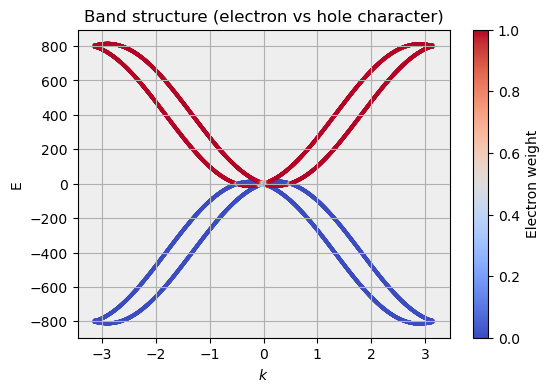

已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\4R.png


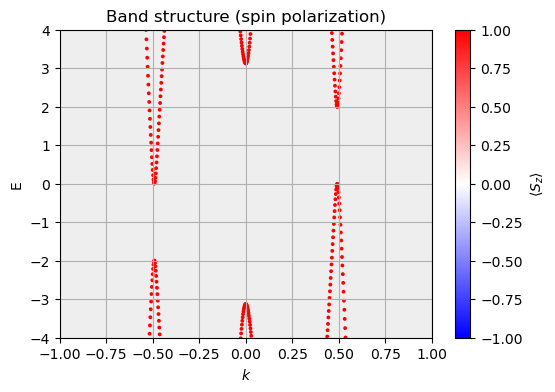

In [5]:
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [s0, np.zeros((2,2))],
    [np.zeros((2,2)), 1*s0]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_r, T_r)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)

if save:
    save_fig_by_title(f"4R_quan")   
plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
plt.ylim(-dela*4,dela*4)
plt.xlim(-1,1)
#plt.xlim(-dela,dela)
if save:
    save_fig_by_title(f"4R")     
plt.show()



已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\3D_quan.png


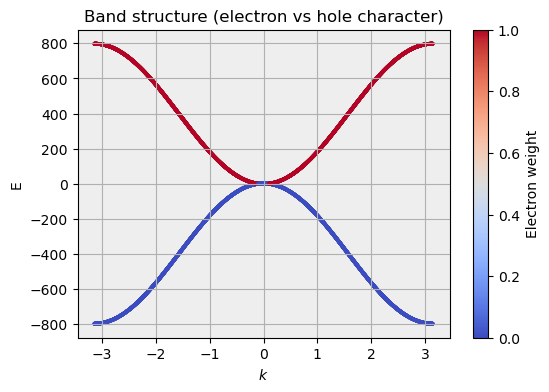

已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\3D.png


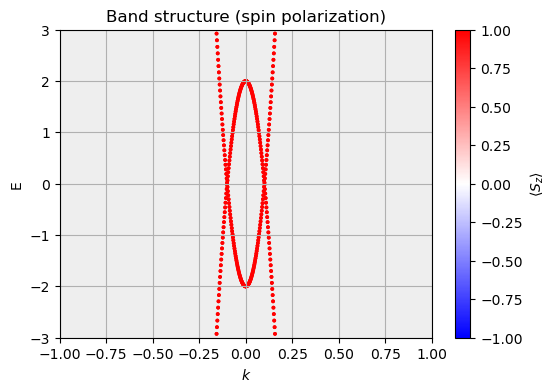

In [6]:
P_e = np.diag([1, 1, 0, 0])
P_h = np.diag([0, 0, 1, 1])
Sz = np.block([
    [s0, np.zeros((2,2))],
    [np.zeros((2,2)), s0]
])

ks = np.linspace(-np.pi, np.pi, 3001)
def Hk(k, H, T):
    return H + T * np.exp(1j*k) + T.conj().T * np.exp(-1j*k)
spin_expect = []
electron_weight = []
energies = []

for k in ks:
    H_k = Hk(k, H_q, T_12)
    evals, evecs = np.linalg.eigh(H_k)

    energies.append(evals)

    # 对每条带计算期望值
    for n in range(len(evals)):
        psi = evecs[:, n]

        w_e = np.real(psi.conj().T @ P_e @ psi)
        s_z = np.real(psi.conj().T @ Sz @ psi)

        electron_weight.append(w_e)
        spin_expect.append(s_z)

energies = np.array(energies)
electron_weight = np.array(electron_weight).reshape(len(ks), -1)
spin_expect = np.array(spin_expect).reshape(len(ks), -1)

from matplotlib.colors import Normalize, TwoSlopeNorm

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')   # 关键：浅灰背景

norm_e = Normalize(vmin=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=electron_weight[:, n],
        cmap='coolwarm',
        norm=norm_e,
        s=3
    )

plt.colorbar(label='Electron weight')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (electron vs hole character)')
plt.grid(True)
#plt.ylim(-2,2)
if save:
    save_fig_by_title(f"3D_quan")   
plt.show()

plt.figure(figsize=(6,4))
ax = plt.gca()
ax.set_facecolor('#eeeeee')

norm_s = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

for n in range(energies.shape[1]):
    plt.scatter(
        ks,
        energies[:, n],
        c=spin_expect[:, n],
        cmap='bwr',
        norm=norm_s,
        s=3
    )

plt.colorbar(label=r'$\langle S_z \rangle$')
plt.xlabel(r'$k$')
plt.ylabel('E')
plt.title('Band structure (spin polarization)')
plt.grid(True)
plt.ylim(-3*dela,3*dela)
plt.xlim(-1,1)
if save:
    save_fig_by_title(f"3D")  
plt.show()



In [7]:
if 2==3:
    phi_set = np.linspace(0, 2*np.pi, 21)     # 超导相位
    sdsd=2
    E_min, E_max = -Delta *sdsd, Delta *sdsd

    phi_list = []
    E_peak_list = []

    for phi in phi_set:
        chaodaojiao = phi
        H_r = H_onsite(hx,hz,saimanjiao,3,chaodaojiao)
        def A_of_E(E):
            G_DD_r, _, _, _ = Gr_DD(
                H_q, H_l, H_r,
                T_12, T_LD, T_l, T_RD, T_r,
                N, E
            )
            return bufeng(G_DD_r)


        peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=20, xtol=1e-5, ftol=1e-5)


        for E_peak in peak_energies:
            phi_list.append(phi)
            E_peak_list.append(E_peak)


    plt.figure(figsize=(6,4))
    plt.scatter(phi_list, E_peak_list, s=6)
    plt.xlabel(r"Superconducting phase $\phi$")
    plt.title(
        fr'ABS' + '\n' +
        fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, gedianshu=2' + '\n' +
        fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
        fr'$m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi$'
    )
    plt.ylabel(r"$E$/ $\Delta$")
    plt.xlim(0, 2*np.pi)
    #plt.ylim(E_min, E_max)
    plt.ylim(E_min, E_max)
    plt.yticks(
        [-Delta*sdsd, -Delta*sdsd/2, 0, Delta*sdsd/2, Delta*sdsd],
        [-1*sdsd, -1*sdsd/2, 0, 1*sdsd/2, 1*sdsd]
    )
    plt.xticks(
        [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
        ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
    )
    plt.show()


<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_30912\1113519900.py:43: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\2ABS ceshi.png


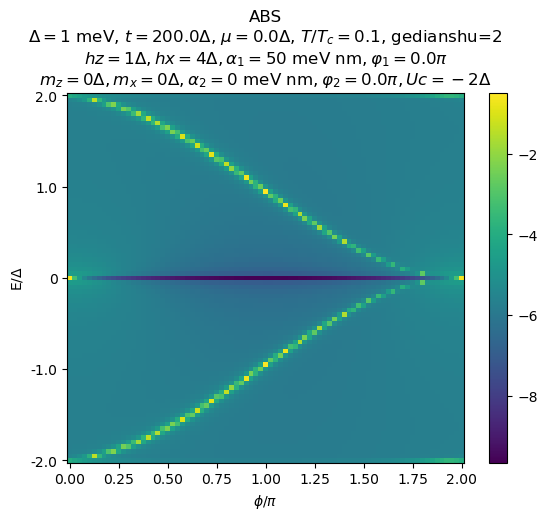

In [8]:
#ABS
num_ef = 80
efmin = -Delta*2
efmax = Delta*2
def_ = (efmax - efmin) / num_ef
num_phi = 80
phi_min =0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r = H_onsite(hx,hz,saimanjiao,3,phi)
        
        # Compute G_DD_r
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_DD_r)

# Figure
plt.figure()
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0,efmax/2, efmax],
    [efmin/Delta, efmin/Delta/2, 0,efmax/Delta/2, efmax/Delta]
)
plt.title(
    fr'ABS' + '\n' +
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, gedianshu=2' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$'
)
plt.axis('square')
plt.axis('tight')
if save:
    save_fig_by_title(f"2ABS ceshi")
plt.show()

In [9]:
shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei+1
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi)

shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi2=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi2)


alnalkna=abs(abs(jjalpi2)-abs(jjalpi))/(abs(jjalpi2)+abs(jjalpi))
print('因子差=',alnalkna)

a2,a3,a4,a5,a6=find_J_extreme_fmin(phi_min=0.5*np.pi, phi_max=1.5*np.pi,
                       N_guess=2, xtol=1e-3, ftol=1e-3,
                       round_digits=6)
print(a2,a3,'\n',a4,a5,'\n',a6)

shumu=int(np.floor(50*dela/(2*np.pi*KBT)))*dianshubei


n*2*np.pi*KBT/Delta= 150.087145653493
这时J(phi/2)= 0.026052166685420514
n*2*np.pi*KBT/Delta= 149.7280854964272
这时J(phi/2)= 0.026051992095430996
因子差= 3.350787990877756e-06
0.16377748133990977 1.0419921870709317 
 -0.24954850043341228 1.9212891884958316 
 0.2075142209195584


In [10]:
#J vs phi
phi_list = np.linspace(0, 2*np.pi, 31)
J_list = []
for phi in phi_list:

    chaodaojiao = phi
    H_r = H_onsite(hx,hz,saimanjiao,3,chaodaojiao)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)

    J_list.append(Jphi)

平移后的系数: a3=1.041992, a5=1.921289
已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\5J vs phi.png


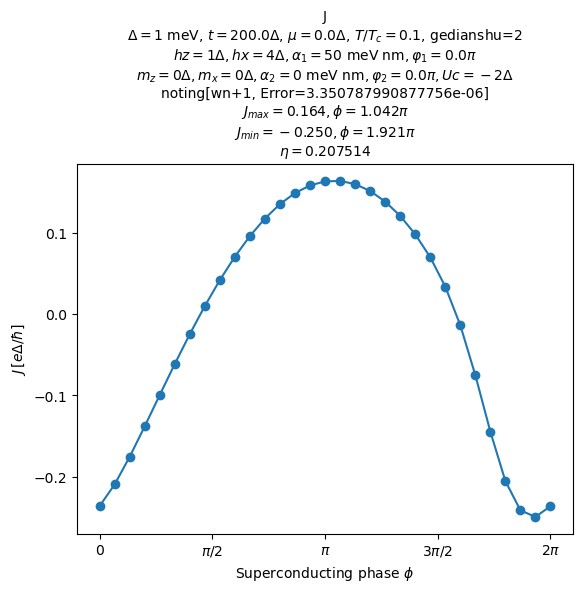

In [11]:
#J vs phi 图
while a3 < 0:
    a3 += 2
while a3 > 2:
    a3 -= 2
while a5 < 0:
    a5 += 2
while a5 > 2:
    a5 -= 2
print(f"平移后的系数: a3={a3:.6f}, a5={a5:.6f}")
plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.title(
    fr'J' + '\n' +
    fr'$\Delta = {dela}$ meV, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$, gedianshu=2' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha_1 = {af}\text{{ meV nm}}, \varphi_1 = {saimanjiao}\pi$' + '\n' +
    fr'$m_z = {mz}\Delta, m_x = {mx}\Delta, \alpha_2 = {af*af2}\text{{ meV nm}}, \varphi_2 = {zhongjian_saimanjiao}\pi, Uc={U_c}\Delta$' + '\n' +
    fr'noting[wn+1, Error={alnalkna}]' + '\n' +
    fr'$J_{{max}} = {a2:.3f}, \phi = {a3:.3f}\pi$' + '\n' +
    fr'$J_{{min}} = {a4:.3f}, \phi = {a5:.3f}\pi$' + '\n' +
    fr'$\eta = {a6:.6f}$',
    fontsize=10
)
if save:
    save_fig_by_title("5J vs phi")
plt.show()

In [12]:
#ABS的流奉献

# --- 1. 构造增强的 phi_set ---
# 请确保在运行前定义了 a3, a5, dela, t, mu, T_Tc, hz, hx, af 等变量
# a3, a5 = 0.3, 0.5 

base_phi = np.linspace(0, 2*np.pi, 31)
# 添加 a3*pi 和 a5*pi 及其极小偏移量点，用于精确捕捉该位置的导数
extra_phi = [
    a3*np.pi, a3*np.pi - 1e-3, a3*np.pi + 1e-3,
    a5*np.pi, a5*np.pi - 1e-3, a5*np.pi + 1e-3
]
# 合并、去重并排序
phi_set = np.sort(np.unique(np.concatenate([base_phi, extra_phi])))

sdsd = 2
E_min, E_max = -Delta * sdsd, 0 

phi_list_1 = []
E_peak_list = []

# --- 2. 核心计算循环 ---
for phi in phi_set:
    chaodaojiao = phi
    H_r = H_onsite(hx, hz, saimanjiao, 3, chaodaojiao)
    
    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)

    # 寻峰逻
    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=30, xtol=1e-5, ftol=1e-5)
    valid_peaks = [E for E in peak_energies if E < 0 and E > E_min]

    if len(valid_peaks) > 0:
        A_values = [A_of_E(E) for E in valid_peaks]
        best_idx = np.argmax(A_values)
        best_E = valid_peaks[best_idx]
        phi_list_1.append(phi)
        E_peak_list.append(best_E)

# 转换为数组以便后续计算
phi_arr = np.array(phi_list_1)
E_arr = np.array(E_peak_list)

# --- 3. 导数计算 ---
dE_dphi = np.gradient(E_arr, phi_arr)

# 提取 a3*pi 和 a5*pi 处的导数值
idx_a3 = np.argmin(np.abs(phi_arr - a3*np.pi))
idx_a5 = np.argmin(np.abs(phi_arr - a5*np.pi))
val_a3 = dE_dphi[idx_a3]
val_a5 = dE_dphi[idx_a5]


<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_30912\1702860289.py:56: SyntaxWarning: invalid escape sequence '\p'
  save_fig_by_title(f"1ABS $\partial E / \partial \phi$")


已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\0ABS.png


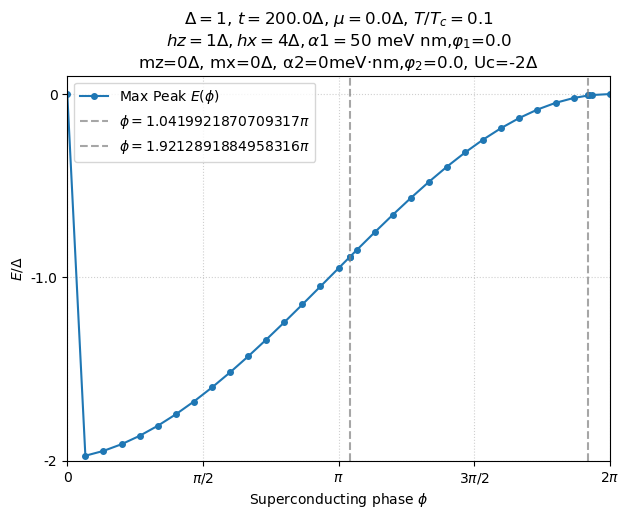

已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\1ABS __partial E _ _partial _phi_.png


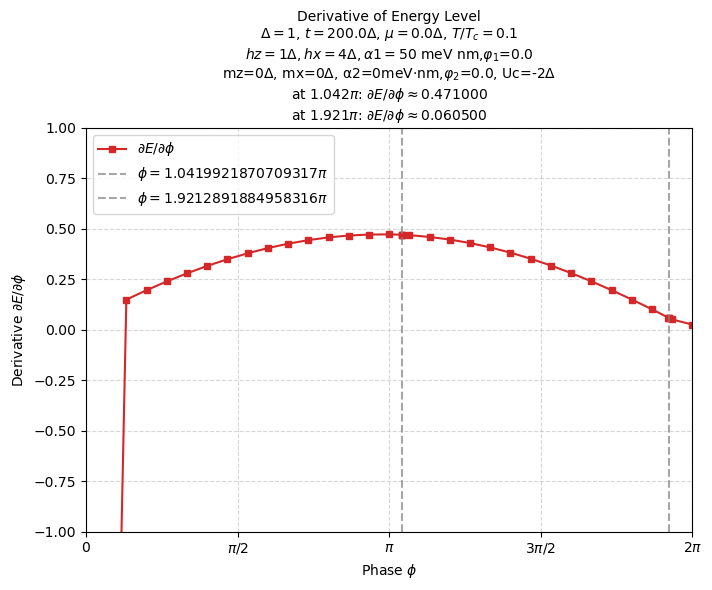

In [13]:
# --- 4. 绘图：能量图 ---
plt.figure(figsize=(7, 5))
# 使用 r 前缀处理 label
plt.plot(phi_list_1, E_peak_list, 'o-', color='tab:blue', markersize=4, label=r'Max Peak $E(\phi)$') 
plt.axvline(x=a3*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi = {a3}\pi$')
plt.axvline(x=a5*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi = {a5}\pi$')

plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E / \Delta$")
# 使用 fr 前缀处理带变量的 LaTeX 标题
plt.title(fr'$\Delta = {dela}$, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha1 = {af}$ meV nm,$\varphi_1$={saimanjiao}' + '\n' + 
    fr'mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,$\varphi_2$={zhongjian_saimanjiao}, Uc={U_c}$\Delta$' )

plt.xlim(0, 2*np.pi)
plt.ylim(E_min, 0.1)
plt.yticks([-dela*sdsd, -dela*sdsd/2, 0], [-1*sdsd, -1*sdsd/2, 0])
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
#plt.xlim(1.79*np.pi,1.81*np.pi)
#plt.ylim(-0.01,0.01)
if save:
    save_fig_by_title(f"0ABS")
plt.show()

# --- 5. 绘图：导数图 ---
plt.figure(figsize=(7, 6)) 
plt.plot(phi_list_1, dE_dphi, 's-', color='tab:red', markersize=4, label=r'$\partial E / \partial \phi$')

# 使用 fr 处理 axvline 的标签
plt.axvline(x=a3*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi = {a3}\pi$')
plt.axvline(x=a5*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi = {a5}\pi$')

plt.xlabel(r"Phase $\phi$")
plt.ylabel(r"Derivative $\partial E / \partial \phi$")

# 使用 fr 格式化大标题，避免转义错误
plt.title(
    fr'Derivative of Energy Level' + '\n' +
    fr'$\Delta = {dela}$, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha1 = {af}$ meV nm,$\varphi_1$={saimanjiao}' + '\n' + 
    fr'mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,$\varphi_2$={zhongjian_saimanjiao}, Uc={U_c}$\Delta$' + '\n' + 
    fr'at ${a3:.3f}\pi$: $\partial E/\partial\phi \approx {val_a3:.6f}$' + '\n' +
    fr'at ${a5:.3f}\pi$: $\partial E/\partial\phi \approx {val_a5:.6f}$',
    fontsize=10
)

plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.ylim(-1,1)
if save:
    save_fig_by_title(f"1ABS $\partial E / \partial \phi$")
plt.show()

In [ ]:
#保存数据（个别点）
folder_path = rf"D:\结果\2026.4.3\{params_str}"
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# 2. 构造报告内容字符串
diff_max = a2 - val_a3
diff_min = a4 - val_a5

report_content = (
    "="*60 + "\n"
    + f"{'ABS CURRENT ANALYSIS REPORT':^60}\n"
    + "="*60 + "\n"
    + f"Parameters: Δ={dela}meV, t={t/dela:.1f}Δ, μ={mu/dela:.1f}Δ, T/Tc={T_Tc}\n"
    + f"            hz={hz}Δ, hx={hx}Δ, α1={af}meV·nm,varphi1={saimanjiao}\n"
    + f"            mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,varphi2={zhongjian_saimanjiao}, Uc={U_c}meV\n"
    + f"            η={a6:.6f}\n"
    + f"            noting[wn+1, The error value caused by the maximum value={alnalkna}]\n"
    + "-" * 60 + "\n"
    + f"[@ Phase φ = {a3:.3f}π]\n"
    + f"  > Total Current (Jmax)        : {a2:10.6f}\n"
    + f"  > Bound State Current (∂E/∂φ) : {val_a3:10.6f}\n"
    + f"  > Difference (Jmax - ∂E/∂φ)   : {diff_max:10.6f}\n"
    + "-" * 60 + "\n"
    + f"[@ Phase φ = {a5:.3f}π]\n"
    + f"  > Total Current (Jmin)        : {a4:10.6f}\n"
    + f"  > Bound State Current (∂E/∂φ) : {val_a5:10.6f}\n"
    + f"  > Difference (Jmin - ∂E/∂φ)   : {diff_min:10.6f}\n"
    + "="*60 + "\n"
)

# 3. 构造文件名并清洗非法字符
# Windows 文件名不能包含 / : * ? " < > |
# 我们将 / 替换为 _, 并移除换行符
raw_filename = (
    f"6Delta={dela}meV_t={t/dela:.1f}D_mu={mu/dela:.1f}D_TTc={T_Tc}_"
    f"hz={hz}D_hx={hx}D_a1={af}_"
    f"mz={mz}D_mx={mx}D_a2={af}"
)
# 替换掉可能导致报错的字符
clean_filename = raw_filename.replace("/", "-").replace(":", "").replace("\n", "").strip()
file_full_path = os.path.join(folder_path, f"{clean_filename}.txt")

# 4. 写入文件并同时在控制台打印
try:
    with open(file_full_path, "w", encoding="utf-8") as f:
        f.write(report_content)
    print(report_content) # 依然在控制台显示
    print(f"--- 报告已成功保存至: {file_full_path} ---")
except Exception as e:
    print(f"保存文件失败: {e}")

NameError: name 'J_final' is not defined

In [ ]:
#ABS current 全相位
# 1. 定义我们真正需要画图的“目标中心点”
base_phi = np.linspace(0, 2*np.pi, 31)
target_centers = np.sort(np.unique(np.concatenate([base_phi, [a3*np.pi, a5*np.pi]])))

# 2. 为所有中心点配备左右辅助点 (+- 1e-3)
phi_with_buffers = np.concatenate([
    target_centers, 
    target_centers - 1e-3, 
    target_centers + 1e-3
])

# 3. 去重排序，生成送入循环的完整计算集
phi_set = np.sort(np.unique(phi_with_buffers))

sdsd = 2
E_min, E_max = -Delta * sdsd, 0 

phi_list_1 = []
E_peak_list = []

# --- 2. 核心计算循环 ---
for phi in phi_set:
    chaodaojiao = phi
    H_r = H_onsite(hx, hz, saimanjiao, 3, chaodaojiao)
    
    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)

    # 寻峰逻辑
    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=10, xtol=1e-5, ftol=1e-5)
    valid_peaks = [E for E in peak_energies if E < 0 and E > E_min]

    if len(valid_peaks) > 0:
        A_values = [A_of_E(E) for E in valid_peaks]
        best_idx = np.argmax(A_values)
        best_E = valid_peaks[best_idx]
        phi_list_1.append(phi)
        E_peak_list.append(best_E)

# 转换为数组
phi_arr_full = np.array(phi_list_1)
E_arr_full = np.array(E_peak_list)

# --- 3. 导数计算与清洗 ---
# A. 利用包含所有辅助点的数据计算出高精度导数
dE_dphi_full = np.gradient(E_arr_full, phi_arr_full)

# B. 创建过滤器(Mask)：只保留那些等于“目标中心点”的元素，剔除掉辅助点
mask = np.array([np.any(np.isclose(p, target_centers, atol=1e-6)) for p in phi_arr_full])

# C. 提取最终只用来画图的纯净数据！
phi_final = phi_arr_full[mask]
E_final = E_arr_full[mask]
dE_dphi_final = dE_dphi_full[mask]

# D. 提取 a3*pi 和 a5*pi 处的导数值 (从清洗后的纯净数组中取)
idx_a3 = np.argmin(np.abs(phi_final - a3*np.pi))
idx_a5 = np.argmin(np.abs(phi_final - a5*np.pi))
val_a3 = dE_dphi_final[idx_a3]
val_a5 = dE_dphi_final[idx_a5]

<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
C:\Users\taoji\AppData\Local\Temp\ipykernel_30912\2472490197.py:56: SyntaxWarning: invalid escape sequence '\p'
  save_fig_by_title(f"1ABS $\partial E / \partial \phi$")


已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\0ABS.png


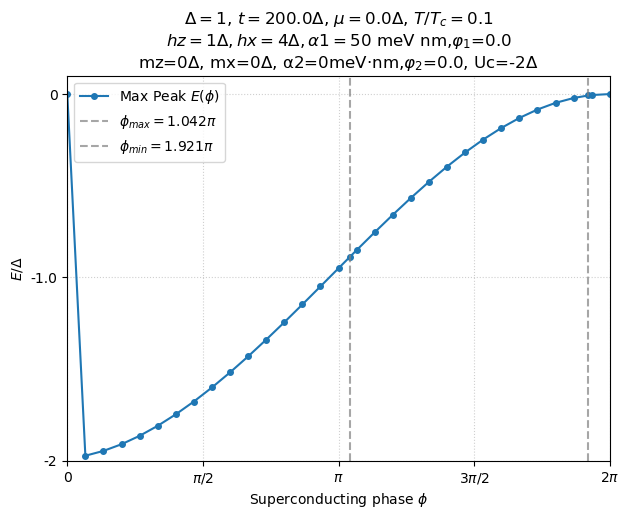

已保存图片: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\1ABS __partial E _ _partial _phi_.png


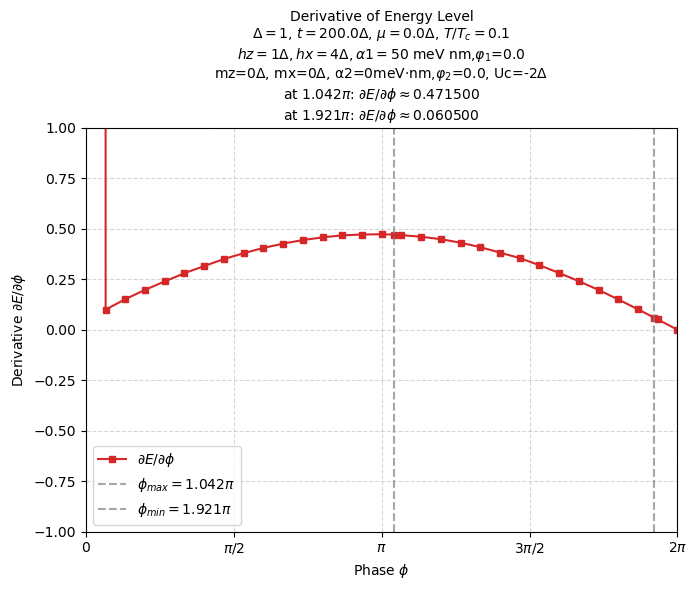

In [16]:
#绘图
plt.figure(figsize=(7, 5))
# 使用 r 前缀处理 label
plt.plot(phi_final, E_final, 'o-', color='tab:blue', markersize=4, label=r'Max Peak $E(\phi)$')
plt.axvline(x=a3*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi_{{max}} = {a3:.3f}\pi$')
plt.axvline(x=a5*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi_{{min}} = {a5:.3f}\pi$')

plt.xlabel(r"Superconducting phase $\phi$")
plt.ylabel(r"$E / \Delta$")
# 使用 fr 前缀处理带变量的 LaTeX 标题
plt.title(fr'$\Delta = {dela}$, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha1 = {af}$ meV nm,$\varphi_1$={saimanjiao}' + '\n' + 
    fr'mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,$\varphi_2$={zhongjian_saimanjiao}, Uc={U_c}$\Delta$' )

plt.xlim(0, 2*np.pi)
plt.ylim(E_min, 0.1)
plt.yticks([-dela*sdsd, -dela*sdsd/2, 0], [-1*sdsd, -1*sdsd/2, 0])
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
#plt.xlim(1.79*np.pi,1.81*np.pi)
#plt.ylim(-0.01,0.01)
if save:
    save_fig_by_title(f"0ABS")
plt.show()

# --- 5. 绘图：导数图 ---
plt.figure(figsize=(7, 6)) 
plt.plot(phi_final, dE_dphi_final, 's-', color='tab:red', markersize=4, label=r'$\partial E / \partial \phi$')

# 使用 fr 处理 axvline 的标签
plt.axvline(x=a3*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi_{{max}} = {a3:.3f}\pi$')
plt.axvline(x=a5*np.pi, color='gray', linestyle='--', alpha=0.7, label=fr'$\phi_{{min}} = {a5:.3f}\pi$')

plt.xlabel(r"Phase $\phi$")
plt.ylabel(r"Derivative $\partial E / \partial \phi$")

# 使用 fr 格式化大标题，避免转义错误
plt.title(
    fr'Derivative of Energy Level' + '\n' +
    fr'$\Delta = {dela}$, $t = {t/dela}\Delta$, $\mu = {mu/dela}\Delta$, $T/T_c = {T_Tc}$' + '\n' +
    fr'$hz = {hz}\Delta, hx = {hx}\Delta, \alpha1 = {af}$ meV nm,$\varphi_1$={saimanjiao}' + '\n' + 
    fr'mz={mz}Δ, mx={mx}Δ, α2={af*af2}meV·nm,$\varphi_2$={zhongjian_saimanjiao}, Uc={U_c}$\Delta$' + '\n' + 
    fr'at ${a3:.3f}\pi$: $\partial E/\partial\phi \approx {val_a3:.6f}$' + '\n' +
    fr'at ${a5:.3f}\pi$: $\partial E/\partial\phi \approx {val_a5:.6f}$',
    fontsize=10
)

plt.xlim(0, 2*np.pi)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.ylim(-1,1)
if save:
    save_fig_by_title(f"1ABS $\partial E / \partial \phi$")
plt.show()

In [17]:
#保存数据
# 1. 构造参数字符串
params_str = (
    f"hz={hz}D_hx={hx}D_a1={af}_jiao={saimanjiao:.3f}_"
    f"mz={mz}D_mx={mx}D_a2={af*af2}_zjiao={zhongjian_saimanjiao:.3f}_Uc={U_c}_"
    f"TTc={T_Tc}_Delta={dela}meV_t={t/dela:.1f}D_mu={mu/dela:.1f}D"
)

# 清洗文件夹名称中的非法字符
for ch in ['\\','/',':','*','?','"','<','>','|']:
    params_str = params_str.replace(ch, '_')

# --- 2. 设置保存根目录 ---
save_dir = rf"D:\结果\2026.4.3\{params_str}"
os.makedirs(save_dir, exist_ok=True)


if save:
    # --- 保存图片 (确保在这之前已经 plt.show() 或者 plt.figure()) ---
    # save_fig_by_title("0ABS_相位与ABS能量")
    # save_fig_by_title("1ABS_导数图")

    # --- 核心新增：将纯净数据输出为 txt ---
    # 将三个一维数组按列合并
    data_to_save = np.column_stack((phi_final, E_final, dE_dphi_final))
    
    # 定义 txt 文件名，直接使用 save_dir
    txt_filename = os.path.join(save_dir, "7相位_能量_导数.txt")
    
    # 使用 numpy 格式化写入，并加上表头 (Header)
    np.savetxt(
        txt_filename, 
        data_to_save, 
        header="phi\t\t\t\t   E\t\t\t  dE_dphi",  # 表头
        fmt="%.8e",                                  # 科学计数法，保留8位小数
        delimiter="\t",                              # 用制表符(Tab)隔开
        comments=""                                  # 去掉默认的 '#' 注释符
    )
    print(f"已保存数据文档: {txt_filename}")

已保存数据文档: D:\结果\2026.4.3\hz=1D_hx=4D_a1=50_jiao=0.000_mz=0D_mx=0D_a2=0_zjiao=0.000_Uc=-2_TTc=0.1_Delta=1meV_t=200.0D_mu=0.0D\7相位_能量_导数.txt
